# **PyTorch Training Pipeline From Scratch**
---

## **Importing Necessary Libraries, Modules and Packages**

In [238]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [239]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [240]:
import torch

---

## **Importing Dataset, Feature and Target Extraction, Train-Test Split and Preprocessing**

In [241]:
df = pd.read_csv("https://raw.githubusercontent.com/gscdit/Breast-Cancer-Detection/refs/heads/master/data.csv")
df.sample(3)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
436,908916,B,12.87,19.54,82.67,509.2,0.09136,0.07883,0.01797,0.0209,0.1861,0.06347,0.3665,0.7693,2.597,26.50,0.005910,0.01362,0.007066,0.006502,0.02223,0.002378,14.450,24.38,95.14,626.9,0.12140,0.16520,0.07127,0.06384,0.3313,0.07735,NaN
258,887181,M,15.66,23.20,110.20,773.5,0.11090,0.31140,0.31760,0.1377,0.2495,0.08104,1.2920,2.4540,10.120,138.50,0.012360,0.05995,0.082320,0.030240,0.02337,0.006042,19.850,31.64,143.70,1226.0,0.15040,0.51720,0.61810,0.24620,0.3277,0.10190,NaN
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.0000,0.1587,0.05884,0.3857,1.4280,2.548,19.15,0.007189,0.00466,0.000000,0.000000,0.02676,0.002783,9.456,30.37,59.16,268.6,0.08996,0.06444,0.00000,0.00000,0.2871,0.07039,NaN


In [242]:
df.shape

(569, 33)

In [243]:
df.drop(columns=["id", "Unnamed: 32"], inplace=True)

In [244]:
X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

In [245]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [246]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [247]:
encoder = LabelEncoder()
y_train = encoder.fit_transform(y_train)
y_test = encoder.transform(y_test)

In [248]:
X_train

array([[-0.53125921, -0.79348006, -0.55413325, ..., -1.02370018,
        -0.67048712, -1.14940104],
       [-1.09827254, -0.68980897, -1.11434527, ..., -1.39395956,
        -0.35029738, -0.56493364],
       [-0.70594513,  1.17396689, -0.65606532, ...,  0.23356926,
        -0.15400015,  0.80987486],
       ...,
       [-0.66012588, -0.43408694, -0.69045703, ..., -0.36578242,
         0.32547998, -0.77455049],
       [-0.54557773,  0.71320648, -0.58106652, ..., -0.79247821,
         0.32387098, -0.13500519],
       [-0.14752291, -0.86259412, -0.19985716, ..., -0.3533086 ,
        -0.59325543, -1.04031472]])

---

## **NumPy Array to Tensor Conversion**

In [249]:
X_train = torch.from_numpy(X_train)
X_test = torch.from_numpy(X_test)
y_train = torch.from_numpy(y_train)
y_test = torch.from_numpy(y_test)

---

## **Defining The Model**

In [250]:
class MySimpleNN():
    def __init__(self, X):
        self.weights = torch.rand(X.shape[1], 1, dtype=torch.float64, requires_grad=True)
        self.bias = torch.zeros(1, dtype=torch.float64, requires_grad=True)

    def forward_pass(self, X):
        Z = torch.matmul(X, self.weights) + self.bias
        y_pred = torch.sigmoid(Z)
        return y_pred

    def loss_fn(self, y_pred, y):
        # clamp
        epsilon = 1e-8
        y_pred = torch.clamp(y_pred, epsilon, 1-epsilon)

        return -(y*torch.log(y_pred) + (1-y)*torch.log(1-y_pred)).mean()

---

## **Training Pipeline**

In [251]:
# CCreating the model and defining parameters
model = MySimpleNN(X_train)
epochs = 50
learning_rate = 0.1

indx = []
loss_list = []

# Defining the loop
for epoch in range(1,epochs):
    # Forward Pass
    y_pred = model.forward_pass(X_train)

    # Loss Calculation
    loss = model.loss_fn(y_pred, y_train)

    # Backward Pass
    loss.backward()

    # Parameter Update
    with torch.no_grad():
        model.weights -= learning_rate * model.weights.grad
        model.bias -= learning_rate * model.bias.grad

    # Zero Grad
    model.weights.grad.zero_()
    model.bias.grad.zero_()

    indx.append(epoch+1)
    loss_list.append(loss.item())

    # Printing the loss in terms of each epochs
    print(f"Epoch {epoch}     :      {loss:.4f}")

Epoch 1     :      3.4749
Epoch 2     :      3.3218
Epoch 3     :      3.1669
Epoch 4     :      3.0040
Epoch 5     :      2.8328
Epoch 6     :      2.6570
Epoch 7     :      2.4777
Epoch 8     :      2.3007
Epoch 9     :      2.1204
Epoch 10     :      1.9456
Epoch 11     :      1.7736
Epoch 12     :      1.6069
Epoch 13     :      1.4504
Epoch 14     :      1.3044
Epoch 15     :      1.1755
Epoch 16     :      1.0658
Epoch 17     :      0.9765
Epoch 18     :      0.9071
Epoch 19     :      0.8557
Epoch 20     :      0.8192
Epoch 21     :      0.7940
Epoch 22     :      0.7766
Epoch 23     :      0.7643
Epoch 24     :      0.7551
Epoch 25     :      0.7479
Epoch 26     :      0.7419
Epoch 27     :      0.7368
Epoch 28     :      0.7323
Epoch 29     :      0.7282
Epoch 30     :      0.7245
Epoch 31     :      0.7210
Epoch 32     :      0.7179
Epoch 33     :      0.7150
Epoch 34     :      0.7124
Epoch 35     :      0.7099
Epoch 36     :      0.7076
Epoch 37     :      0.7055
Epoch 38  

<Axes: >

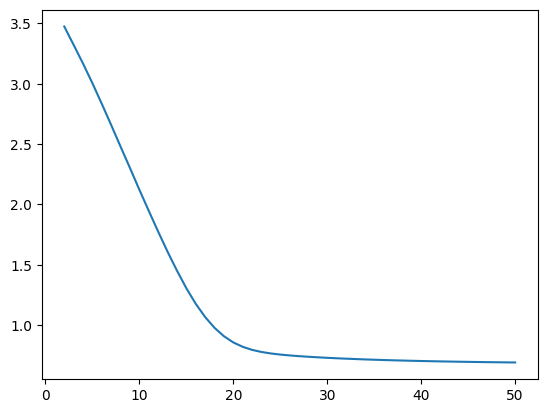

In [252]:
# Visualizing the loss in terms of epochs
sns.lineplot(x=indx, y=loss_list)

---

## **Model Evaluation**

In [253]:
with torch.no_grad(): # To stop tracking
    y_pred = model.forward_pass(X_test)
    y_pred = (y_pred>0.9).float()

y_pred

tensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
      

In [254]:
accuracy = (y_pred == y_test).float().mean()
print(f"Accuracy Score   :    {accuracy.item()*100:.2f}%")

Accuracy Score   :    65.79%


---
---